In [3]:
import pandas as pd
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sqlalchemy import create_engine
from dotenv import load_dotenv


In [4]:
# Carrega as variáveis do arquivo oculto .env
load_dotenv()

# Puxando as credenciais com segurança
db_user = os.getenv("DB_USER")
db_password = urllib.parse.quote_plus(os.getenv("DB_PASSWORD"))
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

# Monta a URI corrigida (Corrigido: db_port)
POSTGRES_URI = f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
engine = create_engine(POSTGRES_URI)

Extraindo dados do Materialized view...


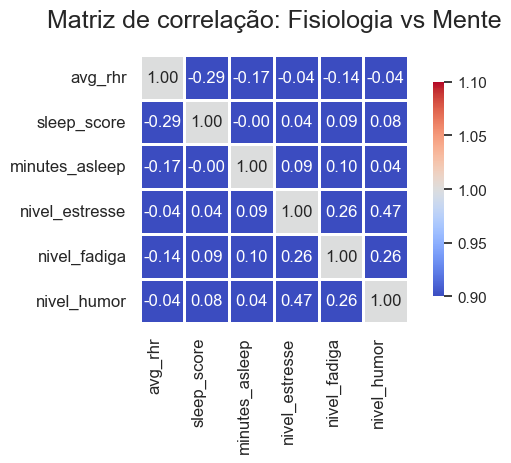

In [3]:
print("Extraindo dados do Materialized view...")
df_analytics = pd.read_sql_query('SELECT * FROM mv_saude_tech_integrada', engine)

# Limpeza rápida, removendo os dias onde o usuário não preencheu o questionário
df_plot = df_analytics.dropna(subset=['nivel_estresse', 'avg_rhr', 'sleep_score']).copy()

# Configuração dos gráficos
sns.set_theme(style="whitegrid")
plt.Figure(figsize=(10, 8))

# Matriz de correlação(Heatmap)
colunas_correlacao = ['avg_rhr', 'sleep_score', 'minutes_asleep', 'nivel_estresse', 'nivel_fadiga', 'nivel_humor']
correlacao = df_plot[colunas_correlacao].corr()

sns.heatmap(correlacao, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            vmin=1, 
            vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": .8})
plt.title('Matriz de correlação: Fisiologia vs Mente', fontsize=18, pad=20)

# Rotacionando as legendas do eixo X para não baterem uma na outra
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

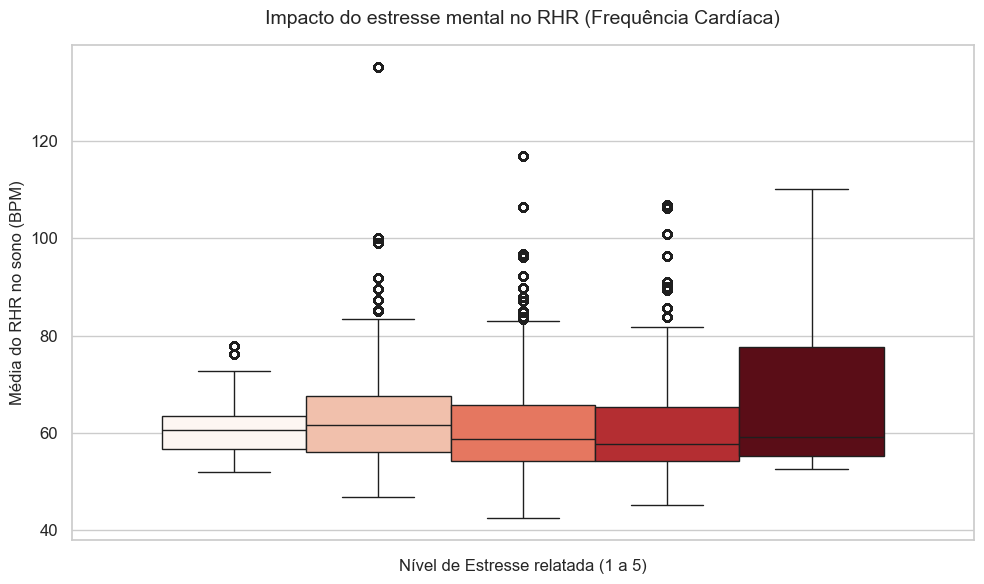

In [9]:
# Gráfico Estresse vs. Batimento de Repouso (RHR)
# Mapeia se o coração bate mais rápido em dias de alto estresse

# Filtro de Qualidade de Dados (Garante apenas notas de 1 a 5)
df_box = df_plot[df_plot['nivel_estresse'].isin([1, 2, 3, 4, 5])].copy()

# Converte para número inteiro (Isso força o gráfico a mostrar os números no eixo X)
df_box['nivel_estresse'] = df_box['nivel_estresse'].astype(int)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(hue='nivel_estresse', 
            y='avg_rhr', 
            data=df_box, 
            palette='Reds', 
            legend=False)

plt.title("Impacto do estresse mental no RHR (Frequência Cardíaca)", fontsize=14, pad=15)
plt.xlabel("Nível de Estresse relatada (1 a 5)", fontsize=12)
plt.ylabel("Média do RHR no sono (BPM)", fontsize=12)

# Aumentando o tamanho dos números dos eixos
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# 4. Resumo da recomendação do Coach
print("Resumo do Load Management (Recomendações do Sistema):")
display(df_analytics['recomendacao_coach'].value_counts().reset_index().rename(columns={'index': 'Status', 'recomendacao_coach': 'Quantidade de Dias'}))

Resumo do Load Management (Recomendações do Sistema):


,Quantidade de Dias,count
0,Carga Moderada,413710
1,Recuperado - pronto para treino,132665
2,Alerta: Focar em saúde mental,7107
